In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("obulisainaren/forest-fire-c4")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 123M/123M [00:01<00:00, 97.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions/2
Contents of base_path (/root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions):
['2']
Contents of path (/root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions/2):
['Forect Fire', 'README.md']


In [ ]:
import os

# Point to the 'Forect Fire' directory inside the dataset
data_path = os.path.join(path, 'Forect Fire')

# List forest fire class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Forest fire classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Forest fire classes found: ['Forest Fire_Tester', 'Forest Fire_Dataset']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions/2/Forect Fire) ---
Found 4823 images. Displaying 6 sample images:


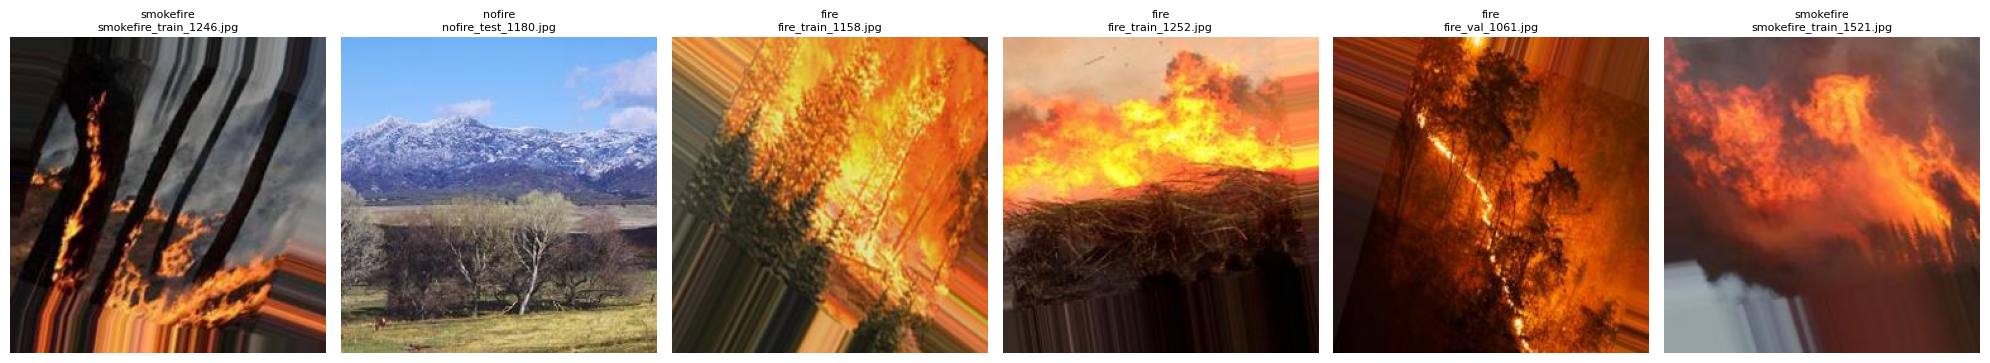

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the updated path pointing to the images folder
data_path = os.path.join(path, 'Forect Fire')
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Data Transformation and Loading
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Build DenseNet Model
model = models.densenet121(weights='IMAGENET1K_V1')
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model initialized with {len(dataset.classes)} classes.")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 194MB/s]


Model initialized with 2 classes.


In [ ]:
# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

Epoch 1/10 - Loss: 0.0467, Acc: 99.07%
Epoch 2/10 - Loss: 0.0296, Acc: 99.53%
Epoch 3/10 - Loss: 0.0293, Acc: 99.56%
Epoch 4/10 - Loss: 0.0257, Acc: 99.56%
Epoch 5/10 - Loss: 0.0281, Acc: 99.56%
Epoch 6/10 - Loss: 0.0272, Acc: 99.56%
Epoch 7/10 - Loss: 0.0307, Acc: 99.53%
Epoch 8/10 - Loss: 0.0279, Acc: 99.56%
Epoch 9/10 - Loss: 0.0238, Acc: 99.56%
Epoch 10/10 - Loss: 0.0248, Acc: 99.53%


In [ ]:
# Model Evaluation Summary
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Test Set Accuracy: {100. * correct / total:.2f}%")

--- Training Summary ---
Final Training Accuracy: 99.53%
Test Set Accuracy: 99.38%


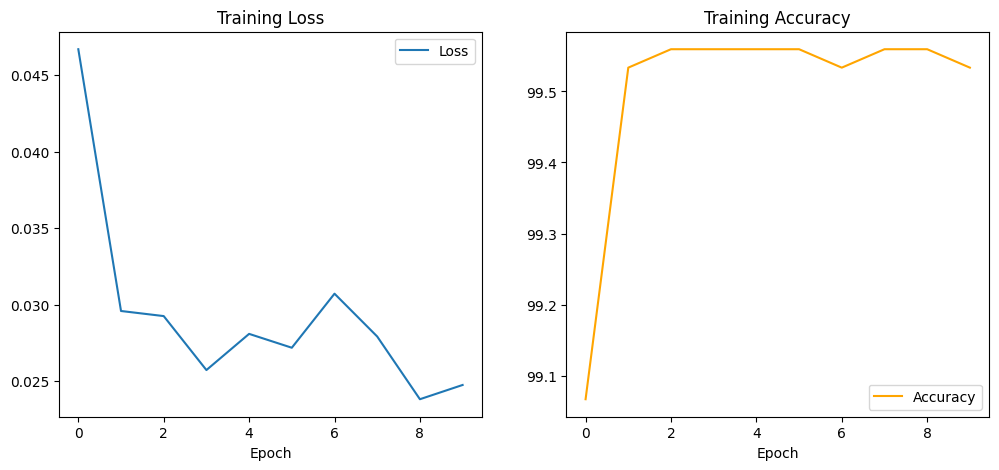

In [ ]:
# Training Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Accuracy', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()